机器学习神经网络计算题
题目描述：
请使用 PyTorch 构建并计算一个三层前馈神经网络（全连接）单次训练的完整过程。网络结构如下：

输入层：4 个神经元

隐藏层1：5 个神经元，激活函数为 Tanh

Dropout层：紧跟在隐藏层1的激活函数之后，丢弃率 p=0.5（请确保在训练模式下执行）

隐藏层2：3 个神经元，激活函数为 ReLU

输出层：2 个神经元（用于二分类），无激活函数（因为 nn.CrossEntropyLoss 会内置 Softmax）

参数与数据：
参数初始化 (请严格按照以下方式初始化，并全部设置 requires_grad=True)：

W1: shape=[5, 4], 所有元素初始化为 0.1

b1: shape=[5], 所有元素初始化为 0.05

W2: shape=[3, 5], 所有元素初始化为 0.2

b2: shape=[3], 所有元素初始化为 0.1

W_out: shape=[2, 3], 所有元素初始化为 0.3

b_out: shape=[2], 所有元素初始化为 0.15

输入特征与标签 (Batch)：
X: torch.tensor([[0.5, 1.0, -1.0, 2.0], [-1.5, 0.0, 1.0, 0.5]], dtype=torch.float32)
y: torch.tensor([1, 0])

计算要求与规则：

Dropout 确定性: 为了使 Dropout 的计算结果唯一，请在调用 Dropout 层之前设置随机种子：torch.manual_seed(42)。

L2 正则化: 仅对 隐藏层1的权重 W1 添加 L2 正则项，正则化系数 λ = 0.01。

损失函数: 使用 nn.CrossEntropyLoss()。
优化: 手动执行 一步 随机梯度下降 (SGD)，学习率 lr = 0.1。

计算步骤:
前向传播:

计算隐藏层1的输出 H1 = Tanh(X @ W1.T + b1)
应用 Dropout: H1_drop = Dropout(H1)

计算隐藏层2的输出 H2 = ReLU(H1_drop @ W2.T + b2)
计算最终输出 Z_out = H2 @ W_out.T + b_out

计算总损失: 总损失 = CrossEntropyLoss + W1的L2正则项

反向传播: 调用 loss.backward()

参数更新: 手动更新 所有 权重和偏置

需要你提供的结果：
请完成计算后，将以下四个结果发给我检查。建议保留4位小数，方便核对。

最终输出 Z_out 的值

包含正则项的总损失 loss 的值

W1 的梯度 W1.grad 的值

经过一步更新后的 W1 的值

期待你的解答！


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")

In [50]:
def forward(w1, w2, w_out, b1, b2, b_out, x):
  torch.manual_seed(42)
  h1 = torch.tanh(x @ w1.T + b1) #shape(2, 5)
  drop_layer1 = nn.Dropout(p=0.5)
  drop_h1 = drop_layer1(h1)

  h2 = torch.relu(drop_h1 @ w2.T +b2) #shape(2, 3)

  z_out = h2 @ w_out.T + b_out #shape(2,2)
  return z_out

epoch: 1 loss: 0.6951 z_out: tensor([[0.5546, 0.5546],
        [0.2940, 0.2940]], grad_fn=<AddBackward0>) w1_grad: <built-in method item of Tensor object at 0x7c5153d2bf50> w1: <built-in method item of Tensor object at 0x7c5153d2bb30>
epoch: 11 loss: 0.6322 z_out: tensor([[0.5530, 0.8199],
        [0.1959, 0.1922]], grad_fn=<AddBackward0>) w1_grad: <built-in method item of Tensor object at 0x7c5153d2bf50> w1: <built-in method item of Tensor object at 0x7c5153d2bb30>
epoch: 21 loss: 0.4340 z_out: tensor([[0.5130, 1.7896],
        [0.2320, 0.0680]], grad_fn=<AddBackward0>) w1_grad: <built-in method item of Tensor object at 0x7c5153d2bf50> w1: <built-in method item of Tensor object at 0x7c5153d2bb30>
epoch: 31 loss: 0.2951 z_out: tensor([[ 0.3361,  2.7518],
        [ 0.3748, -0.0713]], grad_fn=<AddBackward0>) w1_grad: <built-in method item of Tensor object at 0x7c5153d2bf50> w1: <built-in method item of Tensor object at 0x7c5153d2bb30>
epoch: 41 loss: 0.2220 z_out: tensor([[ 0.2071,  3.30

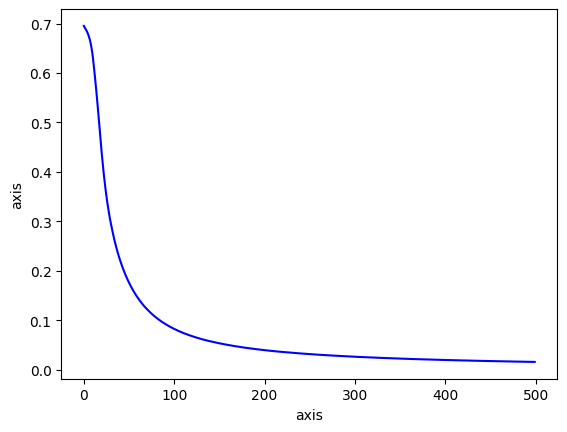

In [52]:
w1 = torch.full((5,4), 0.1, requires_grad=True)
b1 = torch.full((5,), 0.05, requires_grad=True)

w2 = torch.full((3,5), 0.2, requires_grad=True)
b2 = torch.full((3,), 0.1, requires_grad=True)

w_out = torch.full((2,3), 0.3, requires_grad=True)
b_out = torch.full((2,), 0.15, requires_grad=True)

x = torch.tensor([[0.5, 1.0, -1.0, 2.0], [-1.5, 0.0, 1.0, 0.5]], dtype=torch.float32) #shape(2, 4)
y_true = torch.tensor([1,0]) #shape(1,2)

criterion = nn.CrossEntropyLoss()
y_true_index = torch.argmax(y_true)

epochs = 500
lr = 0.1
lambda2 = 0.01
losses = []

for epoch in range(epochs):
  z_out = forward(w1, w2, w_out, b1, b2, b_out, x)
  y_pred = torch.softmax(z_out, dim=1)

  l2 = (w1.pow(2).sum())
  loss = criterion(z_out, y_true) + lambda2 * l2
  losses.append(loss.item())

  loss.backward()

  with torch.no_grad():
    w1 -= lr * w1.grad
    w2 -= lr * w2.grad
    w_out -= lr * w_out.grad

    b1 -= lr * b1.grad
    b2 -= lr * b2.grad
    b_out -= lr * b_out.grad

  w1.grad.zero_()
  w2.grad.zero_()
  w_out.grad.zero_()

  b1.grad.zero_()
  b2.grad.zero_()
  b_out.grad.zero_()

  if epoch %10 == 0:
    print(f"epoch: {epoch+1}",
       f"loss: {loss.item():.4f}",
       f"z_out: {z_out}",
       f"w1_grad: {w1.grad.item}",
       f"w1: {w1.item}")

plt.plot(range(epochs), losses, "blue")
plt.xlabel("axis")
plt.ylabel("axis")
plt.show()